In [ ]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color, filters, feature, morphology, exposure
from skimage.util import img_as_ubyte
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import jaccard_score, accuracy_score, f1_score, classification_report
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
def normalizar_car(array):
    min_val = np.min(array)
    max_val = np.max(array)
    if max_val - min_val == 0: return array
    return (array - min_val) / (max_val - min_val)

def extraer_caracteristicas_pixel(image_rgb):
    caracteristicas = []
    # Preprocesado

    #equalize_adapthist implementa el algoritmo CLAHE: Mejora el contraste de forma local.
    #A diferencia de una ecualización global,
    #esta evita saturar áreas brillantes y ayuda a resaltar detalles en sombras.
    img_eq = exposure.equalize_adapthist(image_rgb, clip_limit=0.03)

    # Filtro gausiano. Aplica un desenfoque para reducir el ruido de alta frecuencia,
    # asegurando que los filtros posteriores
    # no interpreten ruido aleatorio como información relevante.
    img_smooth = filters.gaussian(img_eq, sigma=1, channel_axis=-1)


    gray = color.rgb2gray(img_smooth)

    #HSV Saturación. separar objetos por la pureza de su color,
    hsv = color.rgb2hsv(img_smooth)
    #Lab (a, b) El espacio Lab separa la luminosidad L de los componentes de color a y b.
    lab = color.rgb2lab(img_smooth)

    # recolectamos las características
    caracteristicas.append(img_smooth[:,:,0])
    caracteristicas.append(img_smooth[:,:,1])
    caracteristicas.append(img_smooth[:,:,2])
    caracteristicas.append(hsv[:,:,1])
    caracteristicas.append(normalizar_car(lab[:,:,1]))
    caracteristicas.append(normalizar_car(lab[:,:,2]))

    #Filtro Sobel. Calcula el gradiente de intensidad.
    #Resalta los bordes verticales y horizontales.
    #Sirve para encontrar siluetas
    edge_sobel = filters.sobel(gray)
    caracteristicas.append(normalizar_car(edge_sobel))

    # DoG (Difference of Gaussians)
    # Se obtiene restando una versión muy desenfocada de la imagen de una menos desenfocada.
    # Actúa como un filtro de paso de banda que resalta detalles y bordes
    dog = filters.gaussian(gray, sigma=1) - filters.gaussian(gray, sigma=8)
    caracteristicas.append(normalizar_car(dog))

    # Filtro Frangi
    # Este filtro está diseñado específicamente para detectar estructuras tubulares
    # o filamentosas (como vasos sanguíneos, carreteras o fibras).
    # Utiliza los autovalores de la matriz Hessiana para determinar como de parecido a un tubo es un píxel.
    frangi = filters.frangi(gray, sigmas=range(1, 4), black_ridges=False)
    caracteristicas.append(normalizar_car(frangi))

    # Matriz Hessiana
    # Se calcula a dos escalas (1.5 y 3.5). La matriz Hessiana mide la curvatura local de la intensidad de la imagen.
    # Los autovalores (eigenvalues) resultantes te dicen si estás en una zona plana, en una cresta (borde) o en un rincón.
    # Al extraer eigvals[0], estás capturando la curvatura principal de la superficie de la imagen.

    for escala in [1.5, 3.5]:
        H_elems = feature.hessian_matrix(gray, sigma=escala, order='rc')
        eigvals = feature.hessian_matrix_eigvals(H_elems)
        caracteristicas.append(normalizar_car(eigvals[0]))

    gray_ubyte = img_as_ubyte(gray)
    #mide el desorden o complejidad de las texturas de las que el pixel forma parte
    entropy = filters.rank.entropy(gray_ubyte, morphology.disk(3))
    caracteristicas.append(normalizar_car(entropy))

    #Este filtro resalta los limites de los objetos
    morph_grad = filters.rank.gradient(gray_ubyte, morphology.disk(2))
    caracteristicas.append(normalizar_car(morph_grad))

    return np.stack(caracteristicas, axis=-1)


In [ ]:
def cargar_y_procesar_dataset(dir_base, muestra_pixels=0.05):
    """
    Carga las imágenes, extrae características y devuelve matrices X e y aplanadas.

    Args:
        dir_base: Ruta base donde están las carpetas 'sat' y 'gt'.
        muestra_pixels: Porcentaje de píxeles a tomar de cada imagen para entrenar
                        (0.05 = 5%). Usar el 100% puede agotar la memoria RAM.
    """
    print("Cargando dataset...")
    path_sat = os.path.join(dir_base, "sat", "*.tiff")
    path_gt = os.path.join(dir_base, "gt", "*.tif")

    archivos_sat = sorted(glob.glob(path_sat))
    archivos_gt = sorted(glob.glob(path_gt))

    if len(archivos_sat) == 0:
        print(f"Advertencia: No se encontraron imágenes en {path_sat}")
        return np.array([]), np.array([])

    X_list = []
    y_list = []

    for i, (f_sat, f_gt) in enumerate(zip(archivos_sat, archivos_gt)):
        print(f"Procesando imagen {i+1}/{len(archivos_sat)}: {os.path.basename(f_sat)}")

        # Cargamos imagen y etiqueta
        img = io.imread(f_sat)
        mask = io.imread(f_gt, as_gray=True)

        # Convertimos máscara a binario (0 y 1) estrictamente
        mask = (mask > 0).astype(int)

        # Extraemos características (13 canales)
        features = extraer_caracteristicas_pixel(img)

        # Aplanamos las matrices para que cada fila sea un pixel
        h, w, c = features.shape
        features_flat = features.reshape(-1, c) # (N_pixels, 13)
        mask_flat = mask.reshape(-1)            # (N_pixels,)

        # Submuestreo (Sampling) para evitar colapso de memoria
        # Tomamos aleatoriamente un % de los píxeles de esta imagen
        n_muestras = int(features_flat.shape[0] * muestra_pixels)
        indices = np.random.choice(features_flat.shape[0], n_muestras, replace=False)

        X_list.append(features_flat[indices])
        y_list.append(mask_flat[indices])

    if not X_list:
        return np.array([]), np.array([])

    # Concatenar todos los píxeles de todas las imágenes
    X = np.vstack(X_list)
    y = np.concatenate(y_list)

    print(f"Dataset creado. Dimensiones X: {X.shape}, y: {y.shape}")
    return X, y

In [ ]:
# Definimos ruta
DIR_DATASET = "/content/drive/MyDrive/Archivos .csv/Dataset_Carretera/roads"

In [ ]:
# Generamos el dataset de entrenamiento (se mantiene igual)
X, y = cargar_y_procesar_dataset(DIR_DATASET, muestra_pixels=0.02)

if X.shape[0] > 0:
    # Dividimos en Train y Test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # Definimos SOLO el modelo Random Forest
    modelo_rf = RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)

    print("Modelo Random Forest configurado.")

Cargando dataset...
Procesando imagen 1/20: 10078675_15.tiff


/tmp/ipython-input-2112817939.py:62: FutureWarning: use_gaussian_derivatives currently defaults to False, but will change to True in a future version. Please specify this argument explicitly to maintain the current behavior
  H_elems = feature.hessian_matrix(gray, sigma=escala, order='rc')


Procesando imagen 2/20: 10228675_15.tiff


/tmp/ipython-input-2112817939.py:62: FutureWarning: use_gaussian_derivatives currently defaults to False, but will change to True in a future version. Please specify this argument explicitly to maintain the current behavior
  H_elems = feature.hessian_matrix(gray, sigma=escala, order='rc')


Procesando imagen 3/20: 10228705_15.tiff


...

Procesando imagen 19/20: 10528750_15.tiff


/tmp/ipython-input-2112817939.py:62: FutureWarning: use_gaussian_derivatives currently defaults to False, but will change to True in a future version. Please specify this argument explicitly to maintain the current behavior
  H_elems = feature.hessian_matrix(gray, sigma=escala, order='rc')


Procesando imagen 20/20: 10528765_15.tiff


/tmp/ipython-input-2112817939.py:62: FutureWarning: use_gaussian_derivatives currently defaults to False, but will change to True in a future version. Please specify this argument explicitly to maintain the current behavior
  H_elems = feature.hessian_matrix(gray, sigma=escala, order='rc')


Dataset creado. Dimensiones X: (900000, 13), y: (900000,)


In [ ]:
print("Comienzo del entrenamiento del modelo Random Forest...")

# Entrenamos directamente el modelo
modelo_rf.fit(X_train, y_train)

print("Evaluando Random Forest...")
y_pred = modelo_rf.predict(X_test)

# Cálculo de métricas
acc = accuracy_score(y_test, y_pred)
jac = jaccard_score(y_test, y_pred) # IoU para carreteras (clase 1)
f1 = f1_score(y_test, y_pred)

print(f"Resultados Finales (RF):")
print(f"  -> Accuracy: {acc:.4f}")
print(f"  -> Jaccard (IoU): {jac:.4f}")
print(f"  -> F1-Score: {f1:.4f}")

Comienzo del entrenamiento de modelos
Entrenando Random Forest...
Evaluando Random Forest...
  -> Accuracy: 0.9691, Jaccard: 0.2402, F1: 0.3874
Entrenando SVM (RBF)...
 (Submuestrando datos para SVM por rendimiento...)
Evaluando SVM (RBF)...
  -> Accuracy: 0.9629, Jaccard: 0.0000, F1: 0.0000
Entrenando KNN (k=5)...
Evaluando KNN (k=5)...
  -> Accuracy: 0.9656, Jaccard: 0.2723, F1: 0.4280


In [ ]:
print("Evaluando con Reducción de Dimensionalidad (PCA)")

# Estandarizamos antes de PCA (importante para que las escalas no afecten)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Aplicamos PCA para reducir de 13 a, por ejemplo, 5 componentes principales
pca = PCA(n_components=5)
X_train_pca = pca.fit_transform(X_train_s)
X_test_pca = pca.transform(X_test_s)

print(f"Varianza explicada con 5 componentes: {np.sum(pca.explained_variance_ratio_):.2f}")

Evaluando con Reducción de Dimensionalidad (PCA)
Varianza explicada con 5 componentes: 0.85


In [ ]:
# Re-entrenamos Random Forest con datos reducidos
rf_pca = RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)
rf_pca.fit(X_train_pca, y_train_s)
y_pred_pca = rf_pca.predict(X_test_pca)

jac_pca = jaccard_score(y_test_s, y_pred_pca)
print(f"Random Forest con PCA (5 comp) -> Jaccard: {jac_pca:.4f}")

Random Forest con PCA (5 comp) -> Jaccard: 0.1529


Generando visualización de ejemplo


/tmp/ipython-input-2112817939.py:62: FutureWarning: use_gaussian_derivatives currently defaults to False, but will change to True in a future version. Please specify this argument explicitly to maintain the current behavior
  H_elems = feature.hessian_matrix(gray, sigma=escala, order='rc')


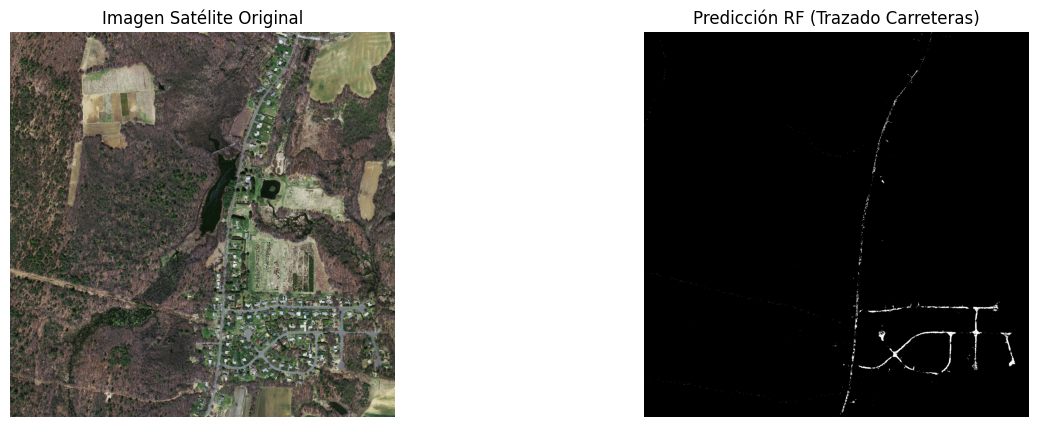

In [ ]:
print("Generando visualización de ejemplo")
archivos_sat = sorted(glob.glob(os.path.join(DIR_DATASET, "sat", "*.tiff")))

if archivos_sat:
    img_demo = io.imread(archivos_sat[0])

    # Extraemos características
    feat_demo = extraer_caracteristicas_pixel(img_demo)
    h, w, c = feat_demo.shape
    feat_flat = feat_demo.reshape(-1, c)

    # Predicción usando el modelo entrenado anteriormente
    pred_flat = modelo_rf.predict(feat_flat)
    pred_img = pred_flat.reshape(h, w)

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img_demo)
    plt.title("Imagen Satélite Original")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(pred_img, cmap='gray')
    plt.title("Predicción Random Forest (Carreteras)")
    plt.axis('off')

    plt.show()